In [1]:
"""
Evaluation against in situ SIF
@V. Tartaglione/F. Maignan
"""
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os
import glob
import seaborn as sns
import csv
import matplotlib.gridspec as gridspec

In [2]:
def calculate_metrics(df, periods):
    """Calculates RMSD and R² for different periods."""
    df = df.dropna()
    results = {}
    for period_name, months in periods.items():
        if period_name == 'Global':
            df_period = df
        else:
            df_period = df[df.index.month.isin(months)]

        if len(df_period) == 0:
            results[period_name] = (np.nan, np.nan)
            continue

        rmsd = np.sqrt(np.mean((df_period['obs'] - df_period['model'])**2))

        valid_mask = ~np.isnan(df_period['obs']) & ~np.isnan(df_period['model'])
        if valid_mask.sum() > 1:
            r2 = np.corrcoef(df_period['obs'][valid_mask], df_period['model'][valid_mask])[0, 1]**2
        else:
            r2 = np.nan

        results[period_name] = (rmsd, r2)
        #print(rmsd,r2)

    return results

In [3]:
def normalize_series(series):
    return (series - series.min()) / (series.max() - series.min())

In [4]:
    # --- Calculate Midday and Weekly Means ---

    def calculate_means(obs_series, model_series, model_series_prior, time_window_start, time_window_end, freq='D'):
      """
      Calculates daily or weekly means for both observation and model
      """
      # Filter data within the time window
      obs_series_window = obs_series.between_time(time_window_start, time_window_end)
      model_series_window = model_series.between_time(time_window_start, time_window_end)
      model_series_prior_window = model_series_prior.between_time(time_window_start, time_window_end)

      # Calculate daily means
      obs_mean_daily = obs_series_window.resample(freq).mean()
      model_mean_daily = model_series_window.resample(freq).mean()
      model_mean_prior_daily = model_series_prior_window.resample(freq).mean()

      # Calculate weekly means
      obs_mean_weekly = obs_mean_daily.resample('W').mean()
      model_mean_weekly = model_mean_daily.resample('W').mean()
      model_mean_prior_weekly = model_mean_prior_daily.resample('W').mean()

      return obs_mean_daily, model_mean_daily, model_mean_prior_daily, obs_mean_weekly, model_mean_weekly, model_mean_prior_weekly



In [5]:
    # --- Calculate Metrics with Common Data ---
    def calculate_means_with_common_data(obs_series, model_series, model_series_prior,time_window_start, time_window_end, freq='D'):
        
        # Filter data within the time window
        obs_series_window = obs_series.between_time(time_window_start, time_window_end)
        model_series_window = model_series.between_time(time_window_start, time_window_end)
        model_series_prior_window = model_series_prior.between_time(time_window_start, time_window_end)

        # Resample to daily to align data points
        obs_daily = obs_series_window.resample('D').asfreq()
        model_daily = model_series_window.resample('D').asfreq()
        model_daily_prior = model_series_prior_window.resample('D').asfreq()

        # Find common dates
        common_dates = obs_daily.index.intersection(model_daily.index)

        # Filter data for common dates
        obs_common = obs_series_window.loc[obs_series_window.index.normalize().isin(common_dates)]
        model_common = model_series_window.loc[model_series_window.index.normalize().isin(common_dates)]
        model_common_prior = model_series_prior_window.loc[model_series_prior_window.index.normalize().isin(common_dates)]

        # Calculate daily means based on common data
        obs_mean_daily = obs_common.resample(freq).mean()
        model_mean_daily = model_common.resample(freq).mean()
        model_mean_prior_daily = model_common_prior.resample(freq).mean()

        # Calculate weekly mean based on daily means
        obs_mean_weekly = obs_mean_daily.resample('W').mean()
        model_mean_weekly = model_mean_daily.resample('W').mean()
        model_mean_prior_weekly = model_mean_prior_daily.resample('W').mean()
        

        return obs_mean_daily, model_mean_daily, model_mean_prior_daily, obs_mean_weekly, model_mean_weekly, model_mean_prior_weekly


In [6]:
def process_site(site_name):
    print(f"\nProcessing {site_name}...")

    # Define file paths and parameters based on site
    if site_name == 'SOBS':
        nc_FluOR_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/SOBS_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_FluOR_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/SIFGPP_Bacour/SOBS_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/SOBS_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/SIFGPP_Leverne/SOBS_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        obs_data_path = '/home/surface9/vtartagl/SIF_is/SOBS_Data.csv'
        base_date = pd.to_datetime('2019-01-01')
        start_date = pd.to_datetime('2019-01-01')
        end_date = pd.to_datetime('2022-01-01')
        time_dim = 'time_52608'
        csv_time_format = '%m/%d/%y %H:%M'
        csv_time_col = 'Time'
        special_site = False
        tz_offset = -6
    elif site_name == 'DEJU':
        nc_FluOR_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/DEJU_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_FluOR_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/SIFGPP_Bacour/DEJU_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/DEJU_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/SIFGPP_Leverne/DEJU_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        obs_data_path = '/home/surface9/vtartagl/SIF_is/DEJU_Data.csv'
        base_date = pd.to_datetime('2019-01-01')
        start_date = pd.to_datetime('2019-01-01')
        end_date = pd.to_datetime('2022-01-01')
        time_dim = 'time_52608'
        csv_time_format = '%m/%d/%y %H:%M'
        csv_time_col = 'Time'
        special_site = False
        tz_offset = -9
    elif site_name == 'US-xDJ':
        nc_FluOR_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/xDJ_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_FluOR_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/xDJ_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/xDJ_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/xDJ_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        obs_data_path = '/home/surface9/vtartagl/SIF_is/DEJU_Data.csv'
        base_date = pd.to_datetime('2019-01-01')
        start_date = pd.to_datetime('2019-01-01')
        end_date = pd.to_datetime('2022-01-01')
        time_dim = 'time_52608'
        csv_time_format = '%m/%d/%y %H:%M'
        csv_time_col = 'Time'
        special_site = False
        tz_offset = 0
    elif site_name == 'US-NR1':
        nc_FluOR_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/US-NR1_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_FluOR_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/SIFGPP_Bacour/US-NR1_HH_Bacour_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path_prior = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/PRIOR/US-NR1_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        nc_Leverne_path = glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/SIF_is/SIFGPP_Leverne/US-NR1_HH_Leverne_NPQ7_GDD/output_*.nc')[0]
        obs_data_path = '/home/users/maignan/PYTHON/ORCHIDEE/FLUORESCENCE/LUCAS/ARTICLE/DATA/niwot_hourly_PNAS_PhotoSpec_v1.2.csv'
        base_date = pd.to_datetime('2017-01-01')
        start_date = pd.to_datetime('2017-01-01')
        end_date = pd.to_datetime('2018-12-31')
        time_dim = 'time_35040'
        csv_time_col = 'DateTime'
        special_site = True
        tz_offset = -6

    # Read and process model outputs
    nc_FluOR = xr.open_dataset(nc_FluOR_path)
    nc_Leverne = xr.open_dataset(nc_Leverne_path)
    
    nc_FluOR_prior = xr.open_dataset(nc_FluOR_path_prior)
    nc_Leverne_prior = xr.open_dataset(nc_Leverne_path_prior)

    # Create time series with timezone adjustment
    nc_times = pd.date_range(start=base_date,
                            periods=len(nc_FluOR[time_dim]),
                            freq='30min')
    nc_times = nc_times + pd.Timedelta(hours=tz_offset)

    # Create series with corrected times
    gpp_FluOR = pd.Series(nc_FluOR.data_site0_var0.values[1], index=nc_times)
    sif_FluOR = pd.Series(nc_FluOR.data_site0_var1.values[1], index=nc_times)
    gpp_Leverne = pd.Series(nc_Leverne.data_site0_var0.values[1], index=nc_times)
    sif_Leverne = pd.Series(nc_Leverne.data_site0_var1.values[1], index=nc_times)

    gpp_FluOR_prior = pd.Series(nc_FluOR_prior.data_site0_var0.values[1], index=nc_times)
    sif_FluOR_prior = pd.Series(nc_FluOR_prior.data_site0_var1.values[1], index=nc_times)
    gpp_Leverne_prior = pd.Series(nc_Leverne_prior.data_site0_var0.values[1], index=nc_times)
    sif_Leverne_prior = pd.Series(nc_Leverne_prior.data_site0_var1.values[1], index=nc_times)

    # Resample model data to hourly for US-NR1
    if site_name == 'US-NR1':
        gpp_FluOR = gpp_FluOR.resample('H').mean()
        sif_FluOR = sif_FluOR.resample('H').mean()
        gpp_Leverne = gpp_Leverne.resample('H').mean()
        sif_Leverne = sif_Leverne.resample('H').mean()

        gpp_FluOR_prior = gpp_FluOR_prior.resample('H').mean()
        sif_FluOR_prior = sif_FluOR_prior.resample('H').mean()
        gpp_Leverne_prior = gpp_Leverne_prior.resample('H').mean()
        sif_Leverne_prior = sif_Leverne_prior.resample('H').mean()

    # Read and process observation data
    if special_site:
        # Special handling for US-NR1
        df_obs = pd.read_csv(obs_data_path, skiprows=[1])
        df_obs = df_obs.rename(columns={
            'Gross Primary Production (GPP)': 'GPP',
            'far-red SIF': 'SIF'
        })
        df_obs[csv_time_col] = pd.to_datetime(df_obs[csv_time_col], utc=True).dt.tz_localize(None)
        df_obs.set_index(csv_time_col, inplace=True)
        df_obs.index = df_obs.index + pd.Timedelta(hours=tz_offset)
    else:
        # Standard handling for other sites
        df_obs = pd.read_csv(obs_data_path)
        df_obs[csv_time_col] = pd.to_datetime(df_obs[csv_time_col], format=csv_time_format)
        df_obs.set_index(csv_time_col, inplace=True)

    # Convert GPP if needed
    if not special_site:
        conversion_factor = (12 / 1e6) * (60 * 60 * 24)
        df_obs['GPP_converted'] = df_obs['GPP'] * conversion_factor
    else:
        df_obs['GPP_converted'] = df_obs['GPP']

    # Calculate daily and weekly means for SIF and GPP for each time window and model
    sif_obs_daily_1130_1230, sif_FluOR_daily_1130_1230, sif_FluOR_prior_daily_1130_1230, sif_obs_weekly_1130_1230, sif_FluOR_weekly_1130_1230, sif_FluOR_prior_weekly_1130_1230 = calculate_means(
        df_obs['SIF'], sif_FluOR, sif_FluOR_prior, '11:30', '12:30'
    )
    _, sif_Leverne_daily_1130_1230, sif_Leverne_prior_daily_1130_1230, _, sif_Leverne_weekly_1130_1230, sif_Leverne_prior_weekly_1130_1230 = calculate_means(
        df_obs['SIF'], sif_Leverne, sif_Leverne_prior, '11:30', '12:30'
    )

    # --- Calculate Metrics with Common Data ---
    sif_obs_daily_1130_1230_common, sif_FluOR_daily_1130_1230_common, sif_FluOR_prior_daily_1130_1230_common, sif_obs_weekly_1130_1230_common, sif_FluOR_weekly_1130_1230_common, sif_FluOR_prior_weekly_1130_1230_common = calculate_means_with_common_data(
     df_obs['SIF'], sif_FluOR, sif_FluOR_prior, '11:30', '12:30'
    )
    _, sif_Leverne_daily_1130_1230_common, sif_Leverne_prior_daily_1130_1230_common, _, sif_Leverne_weekly_1130_1230_common, sif_Leverne_prior_weekly_1130_1230_common = calculate_means_with_common_data(
     df_obs['SIF'], sif_Leverne, sif_Leverne_prior, '11:30', '12:30'
    )

    # Define periods for metrics calculation
    periods = {
        'Global': list(range(1, 13))
    }
    periods_Koba = {
        'Global': list(range(1, 13))
    }

    # Calculate metrics for each time window
    sif_FluOR_metrics_daily_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_daily_1130_1230_common, 'model': sif_FluOR_daily_1130_1230_common}), periods)
    sif_FluOR_prior_metrics_daily_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_daily_1130_1230_common, 'model': sif_FluOR_prior_daily_1130_1230_common}), periods)
    sif_Leverne_metrics_daily_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_daily_1130_1230_common, 'model': sif_Leverne_daily_1130_1230_common}), periods)
    sif_Leverne_prior_metrics_daily_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_daily_1130_1230_common, 'model': sif_Leverne_prior_daily_1130_1230_common}), periods)

    sif_FluOR_metrics_weekly_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_weekly_1130_1230_common, 'model': sif_FluOR_weekly_1130_1230_common}), periods)
    sif_FluOR_prior_metrics_weekly_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_weekly_1130_1230_common, 'model': sif_FluOR_prior_weekly_1130_1230_common}), periods)
    sif_Leverne_metrics_weekly_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_weekly_1130_1230_common, 'model': sif_Leverne_weekly_1130_1230_common}), periods)
    sif_Leverne_prior_metrics_weekly_1130_1230 = calculate_metrics(pd.DataFrame({'obs': sif_obs_weekly_1130_1230_common, 'model': sif_Leverne_prior_weekly_1130_1230_common}), periods)
  
    return (start_date, end_date, 
            sif_obs_daily_1130_1230, sif_FluOR_daily_1130_1230, sif_FluOR_prior_daily_1130_1230, sif_obs_weekly_1130_1230, sif_FluOR_weekly_1130_1230, sif_FluOR_prior_weekly_1130_1230,
            sif_Leverne_daily_1130_1230, sif_Leverne_prior_daily_1130_1230, sif_Leverne_weekly_1130_1230, sif_Leverne_prior_weekly_1130_1230,
            sif_FluOR_metrics_daily_1130_1230,  sif_FluOR_prior_metrics_daily_1130_1230,  sif_Leverne_metrics_daily_1130_1230,  sif_Leverne_prior_metrics_daily_1130_1230,
            sif_FluOR_metrics_weekly_1130_1230, sif_FluOR_prior_metrics_weekly_1130_1230, sif_Leverne_metrics_weekly_1130_1230, sif_Leverne_prior_metrics_weekly_1130_1230)

In [7]:
def create_metrics_table(metrics_dict, model_name, freq):
    """ Creates a table of metrics (RMSD, R²) from the metrics dictionary (returns pd.dataframe)"""
    table_data = []
    for period_name, (rmsd, r2) in metrics_dict.items():
        table_data.append(
            {
                "Model": model_name,
                "Frequency": freq,
                "Period": period_name,
                "RMSD": rmsd,
                "R²": r2,
            }
        )
    return pd.DataFrame(table_data)


Processing DEJU...

Processing SOBS...

Processing US-NR1...


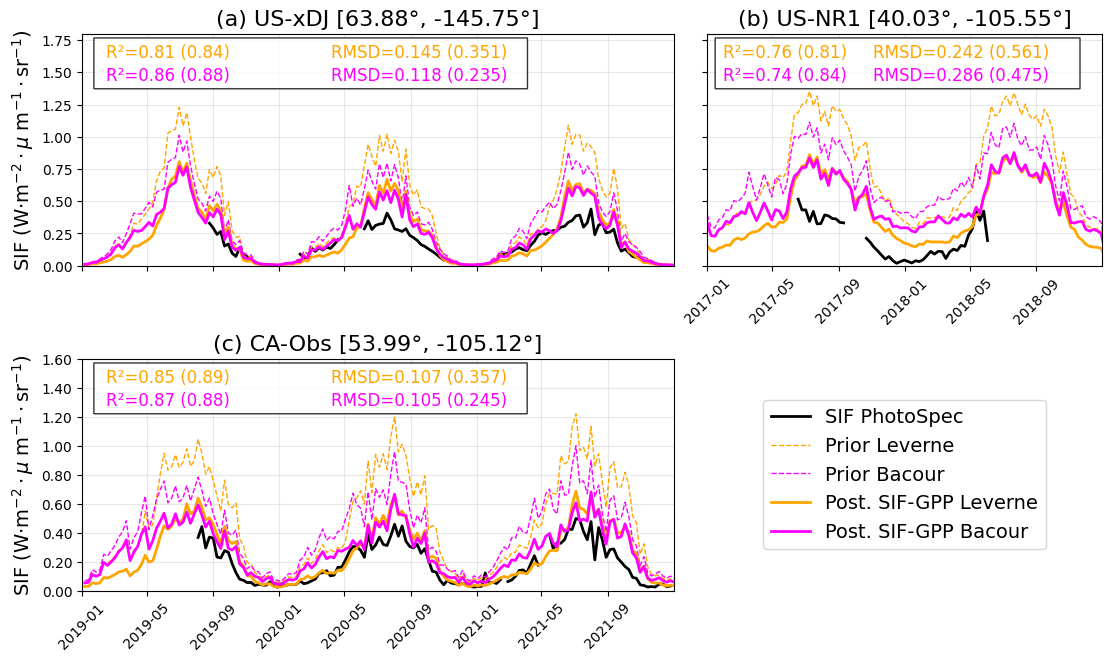

In [8]:
if __name__ == "__main__":
    sites = ['DEJU', 'SOBS', 'US-NR1']
    results = {}
    all_metrics_tables = [] 

    for site in sites:
        try:
            results[site] = process_site(site)
        except Exception as e:
            print(f"Error processing {site}: {str(e)}")
            import traceback
            print(traceback.format_exc())
    
    # Create metrics tables and concatenate 
    for site in sites:
      start_date, end_date, \
      sif_obs_daily_1130_1230, sif_FluOR_daily_1130_1230, sif_FluOR_prior_daily_1130_1230, sif_obs_weekly_1130_1230, sif_FluOR_weekly_1130_1230, sif_FluOR_prior_weekly_1130_1230, \
      sif_Leverne_daily_1130_1230, sif_Leverne_prior_daily_1130_1230, sif_Leverne_weekly_1130_1230, sif_Leverne_prior_weekly_1130_1230, \
      sif_FluOR_metrics_daily_1130_1230,  sif_FluOR_prior_metrics_daily_1130_1230,  sif_Leverne_metrics_daily_1130_1230,  sif_Leverne_prior_metrics_daily_1130_1230, \
      sif_FluOR_metrics_weekly_1130_1230, sif_FluOR_prior_metrics_weekly_1130_1230, sif_Leverne_metrics_weekly_1130_1230, sif_Leverne_prior_metrics_weekly_1130_1230 = results[site]
      
      # Create metrics tables for the current site
      sif_FluOR_daily_table = create_metrics_table(sif_FluOR_metrics_daily_1130_1230, "Bacour", "daily")
      sif_FluOR_prior_daily_table = create_metrics_table(sif_FluOR_prior_metrics_daily_1130_1230, "Bacour_prior", "daily")
      sif_Leverne_daily_table = create_metrics_table(sif_Leverne_metrics_daily_1130_1230, "Leverne", "daily")
      sif_Leverne_prior_daily_table = create_metrics_table(sif_Leverne_prior_metrics_daily_1130_1230, "Leverne_prior", "daily")
      sif_FluOR_weekly_table = create_metrics_table(sif_FluOR_metrics_weekly_1130_1230, "Bacour", "weekly")
      sif_FluOR_prior_weekly_table = create_metrics_table(sif_FluOR_prior_metrics_weekly_1130_1230, "Bacour_prior", "weekly")
      sif_Leverne_weekly_table = create_metrics_table(sif_Leverne_metrics_weekly_1130_1230, "Leverne", "weekly")
      sif_Leverne_prior_weekly_table = create_metrics_table(sif_Leverne_prior_metrics_weekly_1130_1230, "Leverne_prior", "weekly")

      # Add site name to the tables
      sif_FluOR_daily_table.insert(0, "Site", site)
      sif_FluOR_prior_daily_table.insert(0, "Site", site)
      sif_Leverne_daily_table.insert(0, "Site", site)
      sif_Leverne_prior_daily_table.insert(0, "Site", site)
      sif_FluOR_weekly_table.insert(0, "Site", site)
      sif_FluOR_prior_weekly_table.insert(0, "Site", site)
      sif_Leverne_weekly_table.insert(0, "Site", site)
      sif_Leverne_prior_weekly_table.insert(0, "Site", site)

      # Append the tables to the list
      all_metrics_tables.extend([sif_FluOR_daily_table,  sif_FluOR_prior_daily_table,  sif_Leverne_daily_table,  sif_Leverne_prior_daily_table,
                                 sif_FluOR_weekly_table, sif_FluOR_prior_weekly_table, sif_Leverne_weekly_table, sif_Leverne_prior_weekly_table])

    # Concatenate all tables into a single df
    all_metrics_df = pd.concat(all_metrics_tables, ignore_index=True)

    # Reorder columns
    all_metrics_df = all_metrics_df[["Site", "Model", "Frequency", "Period", "RMSD", "R²"]]

    # --- Save to CSV ---

    # 1. Determine the maximum width of each column for alignment
    column_widths = {}
    for col in all_metrics_df.columns:
        if col in ["RMSD", "R²"]:
            column_widths[col] = 5  # Width for "x.xx"
        else:
            column_widths[col] = max(all_metrics_df[col].astype(str).apply(len).max(), len(col)) + 2

    # 2. Create the formatted header row (no changes here)
    header = "".join(f"{col:<{column_widths[col]}}" for col in all_metrics_df.columns)

    # 3. Write to the CSV file (key changes here!)
    with open("post_sif_metrics_table_both.csv", "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([header])

        for _, row in all_metrics_df.iterrows():
            formatted_row = []  # Create a list to store formatted values
            for col in all_metrics_df.columns:
                if col in ["RMSD", "R²"]:
                    # Format to 2 decimal places
                    val = f"{float(row[col]):.2f}"  # Format x.xx
                    formatted_row.append(f"{val:<{column_widths[col]}}")  
                else:
                    formatted_row.append(f"{str(row[col]):<{column_widths[col]}}")

            writer.writerow(["".join(formatted_row)])
    
    # --- Plotting ---

    # Plot settings
    plt.style.use('default')
    months_fmt = mdates.DateFormatter('%Y-%m')

    # Create output directory
    # os.makedirs(f'timeseries/midday/all_data', exist_ok=True)
    # Create a single figure with 3 subplots
    fig = plt.figure(figsize=(11, 6.5), layout='constrained')
    gs = gridspec.GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 1, 1, 1], height_ratios=[1, 1])

    # Subplots
    ax1 = plt.subplot(gs[0, 0:3])   # Top-left spanning three columns
    ax2 = plt.subplot(gs[1, 0:3], sharex=ax1)   # Bottom-left
    ax3 = plt.subplot(gs[0, 3:5], sharey=ax1)   # Top-right spanning two columns
    ax4 = plt.subplot(gs[1, 3:5])   
    
    fontsize_title=16
    fontsize_label=14
    fontsize_legend=14

    df = pd.read_csv('./site_list_new.csv')
    for i, site in enumerate(sites):
        start_date, end_date, \
        sif_obs_daily_1130_1230, sif_FluOR_daily_1130_1230,  sif_FluOR_prior_daily_1130_1230, sif_obs_weekly_1130_1230, sif_FluOR_weekly_1130_1230, sif_FluOR_prior_weekly_1130_1230,\
        sif_Leverne_daily_1130_1230, sif_Leverne_prior_daily_1130_1230, sif_Leverne_weekly_1130_1230, sif_Leverne_prior_weekly_1130_1230,\
        sif_FluOR_metrics_daily_1130_1230, sif_FluOR_prior_metrics_daily_1130_1230, sif_Leverne_metrics_daily_1130_1230, sif_Leverne_prior_metrics_daily_1130_1230, \
        sif_FluOR_metrics_weekly_1130_1230, sif_FluOR_prior_metrics_weekly_1130_1230, sif_Leverne_metrics_weekly_1130_1230, sif_Leverne_prior_metrics_weekly_1130_1230 = results[site]
        
        if site=='DEJU':
            ax=ax1
            lat = df.loc[df.id == 'US-xDJ', 'lat'].iloc[0]
            lon = df.loc[df.id == 'US-xDJ', 'lon'].iloc[0]
            ax.set_title(f"(a) US-xDJ [{lat:.2f}°, {lon:.2f}°]", fontsize=fontsize_title)
            ax.set_ylim(top=1.8)
        elif site=='SOBS':
            ax=ax2
            lat = df.loc[df.id == 'CA-Obs', 'lat'].iloc[0]
            lon = df.loc[df.id == 'CA-Obs', 'lon'].iloc[0]
            ax.set_title(f'(c) CA-Obs [{lat:.2f}°, {lon:.2f}°]', fontsize=fontsize_title)
            ax.set_ylim(top=1.6)
        else:
            ax=ax3
            lat = df.loc[df.id == site, 'lat'].iloc[0]
            lon = df.loc[df.id == site, 'lon'].iloc[0]
            ax.set_title(f'(b) {site} [{lat:.2f}°, {lon:.2f}°]', fontsize=fontsize_title)
        ax.grid(True, alpha=0.3)

        date_range = pd.date_range(start=start_date.replace(day=1),
                                  end=end_date.replace(day=1),
                                  freq='4M').map(lambda x: x.replace(day=1))

        # Plot weekly SIF
        ax.plot(sif_obs_weekly_1130_1230.index, sif_obs_weekly_1130_1230, '-', label='SIF PhotoSpec', color='black', alpha=1, lw=2)
        ax.plot(sif_Leverne_prior_weekly_1130_1230.index, sif_Leverne_prior_weekly_1130_1230, '--', label='Prior Leverne', color='orange', alpha=1, linewidth=1)
        ax.plot(sif_FluOR_prior_weekly_1130_1230.index, sif_FluOR_prior_weekly_1130_1230, '--', label='Prior Bacour', color='magenta', alpha=1, linewidth=1)
        ax.plot(sif_Leverne_weekly_1130_1230.index, sif_Leverne_weekly_1130_1230, '-', label='Post. SIF-GPP Leverne', color='orange', alpha=1, linewidth=2)
        ax.plot(sif_FluOR_weekly_1130_1230.index, sif_FluOR_weekly_1130_1230, '-', label='Post. SIF-GPP Bacour', color='magenta', alpha=1, linewidth=2)

        ax.set_xlim(start_date, end_date)
        ax.set_xticks(date_range)
        ax.xaxis.set_major_formatter(months_fmt)
        ax.tick_params(axis='x', rotation=45)
        
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Format as two decimal places
        
        if i==0:                
            # Remove x-axis ticks and labels
            ax.tick_params(labelbottom=False)
        if i==2:                
            # Hide y-tick labels on the second subplot
            ax.tick_params(labelleft=False)
        if i!=2:
            ax.set_ylabel('SIF (W$\cdot$m$^{-2}\cdot\mu$ m$^{-1}\cdot$sr$^{-1}$)', fontsize=fontsize_label)
        
        # Add metrics as text
        # Filter for this site, model, frequency, and period
        row_Leverne_prior = all_metrics_df.query("Site == @site and Model == 'Leverne_prior' and Frequency == 'weekly' and Period == 'Global'")
        row_Bacour_prior = all_metrics_df.query("Site == @site and Model == 'Bacour_prior' and Frequency == 'weekly' and Period == 'Global'")
        row = all_metrics_df.query("Site == @site and Model == 'Leverne' and Frequency == 'weekly' and Period == 'Global'")
        t1 = ax.text(0.04, 0.90, f'R\u00b2={row["R²"].iloc[0]:.2f} ({row_Leverne_prior["R²"].iloc[0]:.2f})', color='orange', transform=ax.transAxes, fontsize=12)
        t2 = ax.text(0.42, 0.90, f'RMSD={row.RMSD.iloc[0]:.3f} ({row_Leverne_prior.RMSD.iloc[0]:.3f})', color='orange', transform=ax.transAxes, fontsize=12)
        row = all_metrics_df.query("Site == @site and Model == 'Bacour' and Frequency == 'weekly' and Period == 'Global'")
        t3 = ax.text(0.04, 0.80, f'R\u00b2={row["R²"].iloc[0]:.2f} ({row_Bacour_prior["R²"].iloc[0]:.2f})', color='magenta', transform=ax.transAxes, fontsize=12)
        t4 = ax.text(0.42, 0.80, f'RMSD={row.RMSD.iloc[0]:.3f} ({row_Bacour_prior.RMSD.iloc[0]:.3f})', color='magenta', transform=ax.transAxes, fontsize=12)

        # Get bounding boxes of all 4 text objects in axes coordinates
        bboxes = [t.get_window_extent().transformed(ax.transAxes.inverted()) 
        for t in [t1, t2, t3, t4]]

        # Compute enclosing box with some padding
        pad = 0.02
        x0 = min(b.x0 for b in bboxes) - pad
        y0 = min(b.y0 for b in bboxes) - pad
        x1 = max(b.x1 for b in bboxes) - pad
        y1 = max(b.y1 for b in bboxes) + pad

        from matplotlib.patches import FancyBboxPatch
        rect = FancyBboxPatch(
                (x0, y0), x1 - x0, y1 - y0,
                boxstyle='round,pad=0',
                transform=ax.transAxes,
                facecolor='white', edgecolor='black', alpha=0.8,
                zorder=2  # behind text
        )
        ax.add_patch(rect)

        # Bring text to front
        for t in [t1, t2, t3, t4]:
            t.set_zorder(3)        

    # Use the last subplot (bottom-right) for a global legend
    ax4.axis("off")  # Hide the axis
    h, l = ax1.get_legend_handles_labels()
    
    # Place the legend in the empty subplot
    ax4.legend(h, l, loc="center", fontsize=fontsize_legend)
    # Draw the box after rendering to get correct text positions
    fig.canvas.draw()
    plt.show(block=False)
    #plt.savefig(f'./PNG/Figure2.png', dpi=300, bbox_inches='tight')    